<a href="https://colab.research.google.com/github/EmiiFernandez/actividades_data_sciente_ypf/blob/main/C13_Notebook-17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

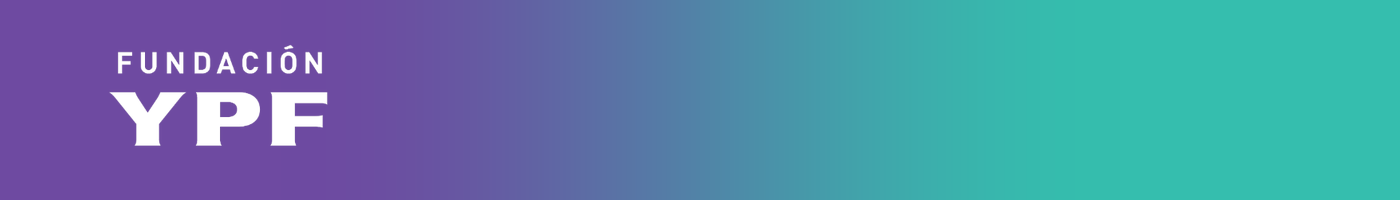

# Fundación YPF - Data Science



# Notebook 17: kNN, SVM, Random Forest y optimización con Optuna

## Índice

- **Parte 0** - Repaso: carga y preparación del dataset
- **Parte 1** - K-Nearest Neighbors (kNN)
- **Parte 2** - Support Vector Machines (SVM)
- **Parte 3** - Random Forest
- **Parte 4** - Comparación de modelos
- **Parte 5** - Optimización de hiperparámetros con Optuna
- **Parte 6** - Ejercicio para las salas

---

## Parte 0 - Repaso: carga y preparación del dataset

Retomamos expectativa de vida, el mismo dataset de las notebooks 12, 13 y 16. Repetimos la preparación ya vista: limpieza, encoding, escalado ajustado solo en train.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
try:
    df = pd.read_csv('/content/life_expectancy_data.csv')
except FileNotFoundError:
    df = pd.read_csv('life_expectancy_data.csv')

In [3]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [4]:
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Life expectancy'])

In [ ]:
cols_numericas = df.select_dtypes(include=[np.number]).columns
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
le_status = LabelEncoder()
df['Status_encoded'] = le_status.fit_transform(df['Status'])

In [ ]:
features = ['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
            'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio',
            'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
            'thinness  1-19 years', 'thinness 5-9 years',
            'Income composition of resources', 'Schooling']

In [ ]:
X = df[features]
y = df['Status_encoded']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

In [ ]:
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Clases: {le_status.classes_}")

Train: 2342 | Test: 586
Clases: ['Developed' 'Developing']


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test_scaled))
print(f"Piso de referencia (clase mayoritaria): {acc_dummy:.3f}")

Piso de referencia (clase mayoritaria): 0.826


In [ ]:
# Árbol de decisión de la Notebook 16, como referencia de comparación
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree_ref = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_ref.fit(X_train_scaled, y_train)
acc_tree_ref = accuracy_score(y_test, tree_ref.predict(X_test_scaled))
print(f"Árbol de decisión (Notebook 16, referencia): {acc_tree_ref:.3f}")

Árbol de decisión (Notebook 16, referencia): 0.945


---

## Parte 1 - K-Nearest Neighbors (kNN)

kNN clasifica cada punto según la etiqueta más frecuente entre sus K vecinos más cercanos. No ajusta parámetros: memoriza los datos de entrenamiento y calcula distancias en el momento de predecir.

Requiere features en la misma escala (ya lo hicimos en la Parte 0), porque la distancia euclídea se distorsiona si una variable tiene un rango mucho mayor que las demás.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"kNN (K=5): {acc_knn:.3f}")
print(classification_report(y_test, y_pred_knn, target_names=le_status.classes_))

kNN (K=5): 0.945
              precision    recall  f1-score   support

   Developed       0.84      0.85      0.84       102
  Developing       0.97      0.96      0.97       484

    accuracy                           0.95       586
   macro avg       0.90      0.91      0.91       586
weighted avg       0.95      0.95      0.95       586



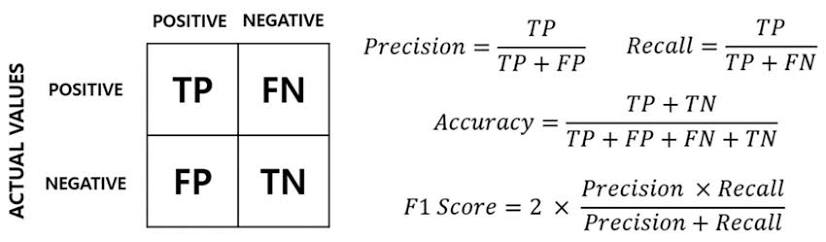

### El efecto de K

La elección de K afecta fuertemente el resultado. Un K muy chico sobreajusta (sigue el ruido de cada punto); un K muy grande suaviza demasiado y pierde matices.

Para elegir K correctamente usamos validación cruzada sobre train, no el resultado en test: mirar el test set para elegir un hiperparámetro y después reportar ese mismo test como resultado final es una fuga de información, igual que ajustar un scaler con todos los datos. El test se toca una sola vez, al final, con el K ya elegido.

In [ ]:
from sklearn.model_selection import cross_val_score as cv_score_knn

In [ ]:
k_values = range(1, 31)
cv_acc_by_k = []

In [ ]:
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    score = cv_score_knn(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    cv_acc_by_k.append(score)

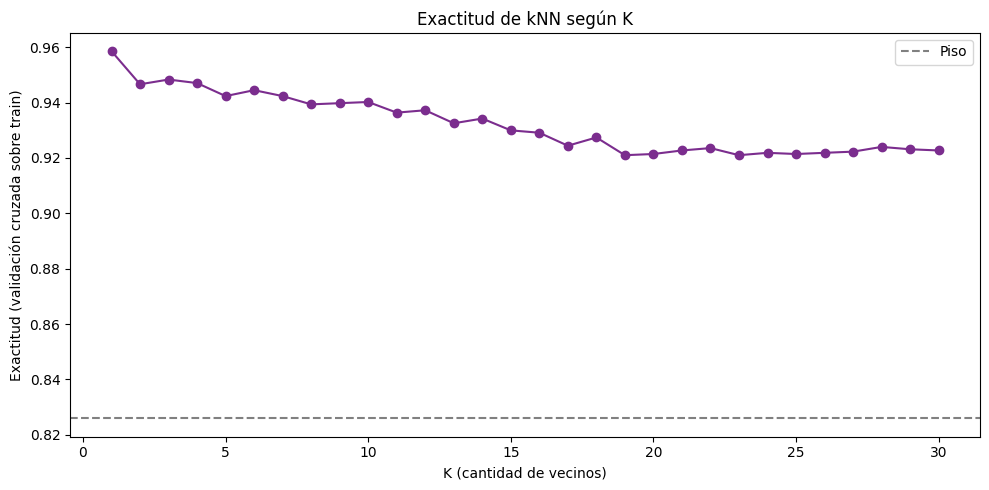

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, cv_acc_by_k, 'o-', color='#7B2D8E')
ax.axhline(y=acc_dummy, color='gray', linestyle='--', label='Piso')
ax.set_xlabel('K (cantidad de vecinos)')
ax.set_ylabel('Exactitud (validación cruzada sobre train)')
ax.set_title('Exactitud de kNN según K')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_k = k_values[np.argmax(cv_acc_by_k)]
print(f"Mejor K según validación cruzada: {best_k} (exactitud CV {max(cv_acc_by_k):.3f})")

In [ ]:
# Recién acá, una sola vez, evaluamos en test con el K elegido
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
acc_knn_best = accuracy_score(y_test, knn_best.predict(X_test_scaled))
print(f"kNN (K={best_k}) en test: {acc_knn_best:.3f}")

---

## Parte 2 - Support Vector Machines (SVM)

SVM busca el hiperplano que separa las clases maximizando el margen entre ellas. Cuando los datos no son separables con una línea recta, usa kernels para proyectarlos a un espacio donde sí lo sean.

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
acc_svm_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
print(f"SVM (kernel lineal): {acc_svm_linear:.3f}")

In [ ]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
acc_svm_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))
print(f"SVM (kernel rbf): {acc_svm_rbf:.3f}")

In [ ]:
print(f"\nReporte del mejor kernel:")
mejor_svm = svm_rbf if acc_svm_rbf >= acc_svm_linear else svm_linear
y_pred_svm = mejor_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm, target_names=le_status.classes_))

---

## Parte 3 - Random Forest

Random Forest entrena muchos árboles sobre distintas muestras y variables, y combina sus resultados por votación. Es más robusto que un único árbol, a costa de perder algo de interpretabilidad.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest (100 árboles): {acc_rf:.3f}")
print(classification_report(y_test, y_pred_rf, target_names=le_status.classes_))

In [ ]:
# Importancia de variables
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
importancias.head(10).plot(kind='barh', ax=ax, color='#00B4D8')
ax.set_xlabel('Importancia')
ax.set_title('Random Forest: importancia de variables (top 10)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## Parte 4 - Comparación de modelos

Reunimos los resultados de todos los modelos, incluyendo el árbol de decisión de la Notebook 16 como referencia.

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Piso (clase mayoritaria)', 'Árbol de decisión (Notebook 16)',
               'kNN (K=5)', f'kNN (K={best_k}, por validación cruzada)', 'SVM (lineal)', 'SVM (rbf)',
               'Random Forest'],
    'Exactitud': [acc_dummy, acc_tree_ref, acc_knn, acc_knn_best,
                  acc_svm_linear, acc_svm_rbf, acc_rf]
}).sort_values('Exactitud', ascending=False).reset_index(drop=True)

In [ ]:
print(resultados.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(resultados['Modelo'], resultados['Exactitud'], color='#7B2D8E')
ax.axvline(x=acc_dummy, color='gray', linestyle='--', label='Piso')
ax.set_xlabel('Exactitud')
ax.set_title('Comparación de modelos')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

---

## Parte 5 - Optimización de hiperparámetros con Optuna

Hasta acá probamos valores de hiperparámetros a mano (K, kernel, n_estimators). Optuna automatiza esa búsqueda: en cada intento (trial) prueba una combinación, mide el resultado, y usa esa información para elegir intentos más prometedores en las siguientes rondas (optimización Bayesiana).

Vamos a optimizar Random Forest, que tiene varios hiperparámetros relevantes: cantidad de árboles, profundidad máxima, y mínimo de muestras por hoja.

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    modelo = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    # Validación cruzada de 3 folds sobre train, para no tocar test todavía
    score = cross_val_score(modelo, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

In [ ]:
print(f"Mejores hiperparámetros: {study.best_params}")
print(f"Mejor exactitud en validación cruzada: {study.best_value:.3f}")

In [ ]:
# Entrenamos el modelo final con los mejores hiperparámetros y evaluamos en test
rf_optuna = RandomForestClassifier(**study.best_params, random_state=42)
rf_optuna.fit(X_train_scaled, y_train)
acc_rf_optuna = accuracy_score(y_test, rf_optuna.predict(X_test_scaled))

In [ ]:
print(f"\nRandom Forest sin optimizar (test): {acc_rf:.3f}")
print(f"Random Forest optimizado con Optuna (test): {acc_rf_optuna:.3f}")

### Historial de la optimización

Cada punto es un trial (intento). Se ve cómo Optuna converge hacia mejores combinaciones a medida que aprende de los intentos anteriores, en vez de probar al azar.

In [ ]:
trials_df = study.trials_dataframe()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.6, color='#00B4D8')
ax.axhline(y=study.best_value, color='#7B2D8E', linestyle='--', label='Mejor valor encontrado')
ax.set_xlabel('Trial')
ax.set_ylabel('Exactitud (validación cruzada)')
ax.set_title('Optuna: evolución de la búsqueda')
ax.legend()
plt.tight_layout()
plt.show()

---

## Parte 6 - Ejercicio para las salas

**Dataset:** `cancer_mamario.csv` (el mismo de la Notebook 16).

**Objetivo:** Entrenar y comparar kNN, SVM y Random Forest contra el árbol de decisión de la Notebook 16, y optimizar uno de ellos con Optuna.

**Tiempo sugerido:** 40 minutos.

### Pasos

1. **Preparación** (5 min): cargar cancer_mamario.csv, reemplazar "?" por NaN, rellenar faltantes, hacer encoding de las variables categóricas (get_dummies), separar en train y test. Esto ya está resuelto en la Notebook 16, parte del anexo; pueden reutilizar ese código.

2. **Entrenar dos modelos** (15 min): elegir al menos dos entre kNN, SVM y Random Forest, entrenarlos y calcular la exactitud en test.

3. **Optimizar con Optuna** (15 min): elegir uno de los dos modelos entrenados y optimizar sus hiperparámetros con Optuna (10-20 trials alcanza). Comparar el resultado antes y después de optimizar.

4. **Comparar contra la Notebook 16** (5 min): armar una tabla con todos los resultados, incluyendo el piso, el árbol de decisión de la Notebook 16 (exactitud test: 0.672 con max_depth=3), y sus modelos nuevos.

### Pistas

- cancer_mamario es un dataset chico (286 filas). Con pocos datos, kNN y SVM pueden no rendir mucho mejor que el árbol; ese es justamente el punto de comparar.
- Para SVM en un dataset con muchas columnas dummy (todas 0/1), probar primero con kernel lineal.
- Optuna necesita una función objetivo que devuelva un número a maximizar (o minimizar). Usen cross_val_score sobre train, igual que en la Parte 5.

### Errores frecuentes a evitar

- Optimizar hiperparámetros mirando el resultado en test: eso es un tipo de fuga de información. Optuna debe evaluar cada trial con validación cruzada sobre train, y test se usa una sola vez al final con el mejor modelo.
- Usar demasiados trials en un dataset chico: con cancer_mamario, 15-20 trials ya exploran el espacio razonablemente.

In [ ]:
# Celda de trabajo para la Parte 6

In [5]:
try:
    df_cancer = pd.read_csv('/content/cancer_mamario.csv')
except FileNotFoundError:
    df_cancer = pd.read_csv('cancer_mamario.csv')

In [6]:
df_cancer.head()

,class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


### **Preparación (5 min):** cargar cancer_mamario.csv, reemplazar "?" por NaN, rellenar faltantes, hacer encoding de las variables categóricas (get_dummies), separar en train y test. Esto ya está resuelto en la Notebook 16, parte del anexo; pueden reutilizar ese código.

In [8]:
df_cancer.columns = df_cancer.columns.str.strip()
df_cancer = df_cancer.replace('?', np.nan)

In [45]:
cols_numericas = df_cancer.select_dtypes(include=[np.number]).columns
df_cancer[cols_numericas] = df_cancer[cols_numericas].fillna(df_cancer[cols_numericas].mode())

In [46]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [47]:
y_cancer = (df_cancer['class'] == 'recurrence-events').astype(int)
X_cancer = pd.get_dummies(df_cancer.drop(columns=['class']), drop_first=True)

In [48]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

### **Entrenar dos modelos** (15 min): elegir al menos dos entre kNN, SVM y Random Forest, entrenarlos y calcular la exactitud en test.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

In [49]:
scaler = StandardScaler()
X_train_scaled_c = pd.DataFrame(scaler.fit_transform(X_train_c), columns=X_train_c.columns, index=X_train_c.index)
X_test_scaled_c = pd.DataFrame(scaler.transform(X_test_c), columns=X_test_c.columns, index=X_test_c.index)

In [50]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_c, y_train_c)
y_pred_knn = knn.predict(X_test_scaled_c)

In [51]:
print(f"Train: {len(X_train_c)} | Test: {len(X_test_c)}")
print(f"Clases: {y_cancer.unique()}")

Train: 228 | Test: 58
Clases: [0 1]


In [52]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

In [53]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled_c, y_train_c)
acc_dummy = accuracy_score(y_test_c, dummy.predict(X_test_scaled_c))
print(f"Piso de referencia (clase mayoritaria): {acc_dummy:.3f}")

Piso de referencia (clase mayoritaria): 0.707


In [54]:
from sklearn.tree import DecisionTreeClassifier


In [55]:
tree_ref = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_ref.fit(X_train_scaled_c, y_train_c)
acc_tree_ref = accuracy_score(y_test_c, tree_ref.predict(X_test_scaled_c))
print(f"Árbol de decisión: {acc_tree_ref:.3f}")

Árbol de decisión: 0.672


# **K-Nearest Neighbors (kNN)**

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [56]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_c, y_train_c)
y_pred_knn_c = knn.predict(X_test_scaled_c)

In [57]:
acc_knn = accuracy_score(y_test_c, y_pred_knn_c)
print(f"kNN (K=5): {acc_knn:.3f}")
print(classification_report(y_test_c, y_pred_knn_c, target_names=['no-recurrence-events', 'recurrence-events']))

kNN (K=5): 0.741
                      precision    recall  f1-score   support

no-recurrence-events       0.74      0.98      0.84        41
   recurrence-events       0.75      0.18      0.29        17

            accuracy                           0.74        58
           macro avg       0.75      0.58      0.56        58
        weighted avg       0.74      0.74      0.68        58



In [58]:
from sklearn.model_selection import cross_val_score as cv_score_knn

In [59]:
k_values_c = range(1, 31)
cv_acc_by_k_c = []

In [60]:
for k in k_values_c:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    score = cv_score_knn(knn_temp, X_train_scaled_c, y_train_c, cv=5, scoring='accuracy').mean()
    cv_acc_by_k_c.append(score)

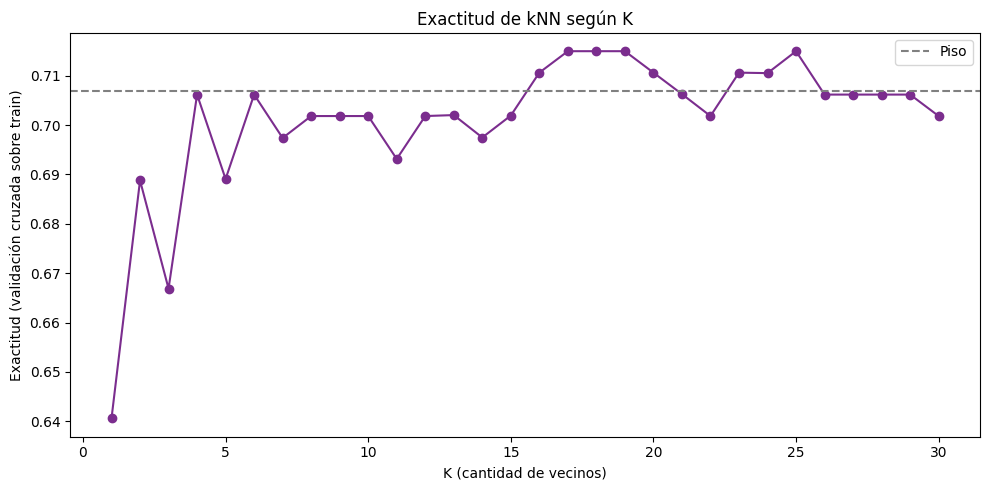

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values_c, cv_acc_by_k_c, 'o-', color='#7B2D8E')
ax.axhline(y=acc_dummy, color='gray', linestyle='--', label='Piso')
ax.set_xlabel('K (cantidad de vecinos)')
ax.set_ylabel('Exactitud (validación cruzada sobre train)')
ax.set_title('Exactitud de kNN según K')
ax.legend()
plt.tight_layout()
plt.show()

In [62]:
best_k_c = k_values[np.argmax(cv_acc_by_k_c)]
print(f"Mejor K según validación cruzada: {best_k_c} (exactitud CV {max(cv_acc_by_k_c):.3f})")

Mejor K según validación cruzada: 17 (exactitud CV 0.715)


In [63]:
# Recién acá, una sola vez, evaluamos en test con el K elegido
knn_best_c = KNeighborsClassifier(n_neighbors=best_k_c)
knn_best_c.fit(X_train_scaled_c, y_train_c)
acc_knn_best_c = accuracy_score(y_test_c, knn_best_c.predict(X_test_scaled))
print(f"kNN (K={best_k_c}) en test: {acc_knn_best_c:.3f}")

kNN (K=17) en test: 0.690


# **Support Vector Machines (SVM)**

In [64]:
from sklearn.svm import SVC

In [ ]:
svm_linear_c = SVC(kernel='linear', random_state=42)
svm_linear_c.fit(X_train_scaled, y_train)
acc_svm_linear_c = accuracy_score(y_test, svm_linear_c.predict(X_test_scaled))
print(f"SVM (kernel lineal): {acc_svm_linear_c:.3f}")

---

## Anexo: Solución sugerida de la Parte 6

*Si se quiere entregar una versión sin soluciones, borrar desde acá hasta el final del notebook.*

In [ ]:
# Preparación (igual que en el anexo de la Notebook 16)
try:
    df_cancer = pd.read_csv('/content/cancer_mamario.csv')
except FileNotFoundError:
    df_cancer = pd.read_csv('cancer_mamario.csv')

In [ ]:
df_cancer = df_cancer.replace('?', np.nan)
for col in df_cancer.columns:
    if df_cancer[col].isnull().sum() > 0:
        df_cancer[col] = df_cancer[col].fillna(df_cancer[col].mode()[0])

In [ ]:
y_cancer = (df_cancer['class'] == 'recurrence-events').astype(int)
X_cancer = pd.get_dummies(df_cancer.drop(columns=['class']), drop_first=True)

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

In [ ]:
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [ ]:
# Piso y árbol de referencia (de la Notebook 16)
dummy_c = DummyClassifier(strategy='most_frequent')
dummy_c.fit(X_train_c_scaled, y_train_c)
acc_piso_c = accuracy_score(y_test_c, dummy_c.predict(X_test_c_scaled))

In [ ]:
tree_c = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_c.fit(X_train_c, y_train_c)
acc_tree_c = accuracy_score(y_test_c, tree_c.predict(X_test_c))

In [ ]:
# kNN
knn_c = KNeighborsClassifier(n_neighbors=5)
knn_c.fit(X_train_c_scaled, y_train_c)
acc_knn_c = accuracy_score(y_test_c, knn_c.predict(X_test_c_scaled))

In [ ]:
# SVM
svm_c = SVC(kernel='linear', random_state=42)
svm_c.fit(X_train_c_scaled, y_train_c)
acc_svm_c = accuracy_score(y_test_c, svm_c.predict(X_test_c_scaled))

In [ ]:
# Random Forest
rf_c = RandomForestClassifier(n_estimators=100, random_state=42)
rf_c.fit(X_train_c, y_train_c)
acc_rf_c = accuracy_score(y_test_c, rf_c.predict(X_test_c))

In [ ]:
# Optuna sobre Random Forest
def objective_cancer(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 2, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    modelo = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, random_state=42
    )
    return cross_val_score(modelo, X_train_c, y_train_c, cv=3, scoring='accuracy').mean()

In [ ]:
study_c = optuna.create_study(direction='maximize')
study_c.optimize(objective_cancer, n_trials=20, show_progress_bar=False)

In [ ]:
rf_c_optuna = RandomForestClassifier(**study_c.best_params, random_state=42)
rf_c_optuna.fit(X_train_c, y_train_c)
acc_rf_c_optuna = accuracy_score(y_test_c, rf_c_optuna.predict(X_test_c))

In [ ]:
print("=" * 60)
print("RESULTADOS: cancer_mamario, comparado con la Notebook 16")
print("=" * 60)
print(f"{'Modelo':<40} {'Exactitud test':>15}")
print("-" * 60)
print(f"{'Piso (clase mayoritaria)':<40} {acc_piso_c:>15.3f}")
print(f"{'Árbol de decisión (Notebook 16)':<40} {acc_tree_c:>15.3f}")
print(f"{'kNN (K=5)':<40} {acc_knn_c:>15.3f}")
print(f"{'SVM (lineal)':<40} {acc_svm_c:>15.3f}")
print(f"{'Random Forest':<40} {acc_rf_c:>15.3f}")
print(f"{'Random Forest + Optuna':<40} {acc_rf_c_optuna:>15.3f}")
print()
print("Con un dataset chico como este, kNN y SVM no siempre superan al árbol,")
print("y Optuna mejora el resultado pero dentro de un margen limitado: no hay")
print("hiperparámetros que compensen la falta de datos o de señal predictiva.")